In [47]:
!pip install opencv-python librosa matplotlib numpy pandas scipy
!pip install openai-whisper
!pip install sentence-transformers

In [48]:
import cv2
import librosa
import whisper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

from scipy.spatial.distance import cosine
from sentence_transformers import SentenceTransformer

In [49]:
INPUT_VIDEO = "/kaggle/input/datasets/ravigiri20027/jj-clip/TRY_NOT_TO_LAUGH_African_Edition_2_720P.mp4"

PROCESSED_VIDEO = "processed.mp4"
AUDIO_FILE = "audio.wav"

# resize + normalize fps
subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    INPUT_VIDEO,
    "-vf",
    "scale=640:360",
    "-r",
    "24",
    PROCESSED_VIDEO
])

# extract mono audio
subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    PROCESSED_VIDEO,
    "-ar",
    "16000",
    "-ac",
    "1",
    AUDIO_FILE
])

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args=['ffmpeg', '-y', '-i', 'processed.mp4', '-ar', '16000', '-ac', '1', 'audio.wav'], returncode=0)

In [50]:
model = whisper.load_model("base")

result = model.transcribe(AUDIO_FILE)

segments = result["segments"]

transcript_df = pd.DataFrame([
    {
        "start": s["start"],
        "end": s["end"],
        "text": s["text"]
    }
    for s in segments
])

transcript_df.head()

,start,end,text
0,0.00,2.56,"Yo, what's up? It's WakerSyalahGDMET."
1,2.56,4.24,The end of the year is near.
2,4.24,9.20,"So of course, we have to squeeze out some mor..."
3,9.20,11.52,"Uh, we got a batch of funny clips."
4,11.52,13.44,"You know, I mean, you already know how these ..."


In [51]:
cap = cv2.VideoCapture(PROCESSED_VIDEO)

VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)
SAMPLE_EVERY = 5

motion_scores = []
motion_times = []

prev = None
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % SAMPLE_EVERY != 0:
        frame_idx += 1
        continue

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    timestamp = frame_idx / VIDEO_FPS

    if prev is not None:
        diff = cv2.absdiff(prev, gray)
        motion_scores.append(diff.mean())
        motion_times.append(timestamp)

    prev = gray
    frame_idx += 1

cap.release()

print(f"Video FPS: {VIDEO_FPS}")
print(f"Motion samples: {len(motion_scores)}")
print(f"Duration: {motion_times[-1]:.1f}s")


In [52]:
HOP_LENGTH = 512
y, sr = librosa.load(AUDIO_FILE)

rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)[0]
times = librosa.times_like(rms, sr=sr, hop_length=HOP_LENGTH)

# Adaptive threshold: 20th percentile of non-zero samples.
# Hardcoded 0.02 was wrong for any video that isn't specifically loud.
nonzero_rms = rms[rms > 0]
silence_threshold = float(np.percentile(nonzero_rms, 20)) if len(nonzero_rms) else 0.02

silence_regions = rms < silence_threshold

print(f"Average energy   : {rms.mean():.5f}")
print(f"Silence threshold: {silence_threshold:.5f}  (adaptive 20th-pct)")
print(f"Silence %        : {silence_regions.mean() * 100:.1f}%")


In [ ]:
# Align motion, audio RMS, and speech rate onto a shared 1-second grid.
# continuity_per_sec is added in the cell right after continuity_scores is built.

VIDEO_DURATION = int(motion_times[-1]) if motion_times else 0
motion_arr   = np.array(motion_scores)
motion_t_arr = np.array(motion_times)

motion_per_second   = np.zeros(VIDEO_DURATION)
rms_per_second      = np.zeros(VIDEO_DURATION)
speech_rate_per_sec = np.zeros(VIDEO_DURATION)

for sec in range(VIDEO_DURATION):
    m_mask = (motion_t_arr >= sec) & (motion_t_arr < sec + 1)
    if m_mask.any():
        motion_per_second[sec] = motion_arr[m_mask].mean()

    r_mask = (times >= sec) & (times < sec + 1)
    if r_mask.any():
        rms_per_second[sec] = rms[r_mask].mean()

for _, row in transcript_df.iterrows():
    words = len(row["text"].strip().split())
    dur   = max(row["end"] - row["start"], 0.1)
    wps   = words / dur
    for sec in range(int(row["start"]), min(int(row["end"]) + 1, VIDEO_DURATION)):
        speech_rate_per_sec[sec] = wps

# Percentile-based thresholds — relative to this video, not hardcoded
motion_low  = float(np.percentile(motion_per_second, 25))
motion_high = float(np.percentile(motion_per_second, 75))
rms_low     = float(np.percentile(rms_per_second[rms_per_second > 0], 20)) if (rms_per_second > 0).any() else silence_threshold
rms_high    = float(np.percentile(rms_per_second, 75))
active_wps  = speech_rate_per_sec[speech_rate_per_sec > 0]
avg_speech_rate = float(active_wps.mean()) if len(active_wps) else 2.5

print(f"Aligned duration : {VIDEO_DURATION}s")
print(f"Motion thresholds: low={motion_low:.1f}  high={motion_high:.1f}")
print(f"RMS silence floor: {rms_low:.5f}")
print(f"Avg speech rate  : {avg_speech_rate:.1f} words/sec")


In [53]:
plt.figure(figsize=(15, 4))
plt.plot(times, rms, linewidth=0.8, alpha=0.8)
plt.axhline(silence_threshold, color='r', linestyle='--', label=f"silence threshold ({silence_threshold:.4f})")
plt.title("Audio Energy Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RMS Energy")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
# Use the video's own energy percentiles rather than hardcoded 0.03 / 0.08
p25_rms = float(np.percentile(rms, 25))
p75_rms = float(np.percentile(rms, 75))

def classify_silence(index, rms, window=10):
    before = np.mean(rms[max(0, index - window):index])
    after  = np.mean(rms[index:min(len(rms), index + window)])
    if before > p75_rms and after > p75_rms:
        return "dramatic_pause"
    elif before < p25_rms and after < p25_rms:
        return "dead_silence"
    else:
        return "neutral_pause"

silence_analysis = []
for i, silent in enumerate(silence_regions):
    if silent:
        silence_analysis.append({
            "time": float(times[i]),
            "type": classify_silence(i, rms)
        })

summary = pd.DataFrame(silence_analysis)
print(f"Total silence regions : {len(silence_analysis)}")
if len(silence_analysis):
    print(summary["type"].value_counts().to_string())


In [55]:
embedder = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

embeddings = embedder.encode(
    transcript_df["text"].tolist()
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


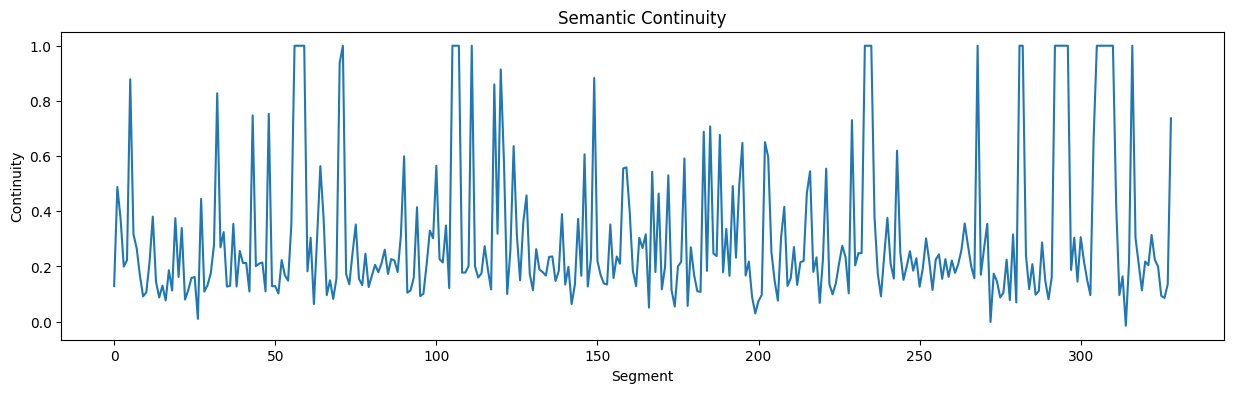

In [56]:
continuity_scores = []

for i in range(1, len(embeddings)):

    similarity = 1 - cosine(
        embeddings[i-1],
        embeddings[i]
    )

    continuity_scores.append(similarity)

plt.figure(figsize=(15,4))

plt.plot(continuity_scores)

plt.title("Semantic Continuity")
plt.xlabel("Segment")
plt.ylabel("Continuity")

plt.show()

In [ ]:
# Map continuity_scores onto the 1-second grid.
# Kept separate because continuity_scores is built just above.

continuity_per_sec = np.full(VIDEO_DURATION, 0.5)  # neutral default

for i in range(len(continuity_scores)):
    if i + 1 >= len(transcript_df):
        break
    row = transcript_df.iloc[i + 1]
    for sec in range(int(row["start"]), min(int(row["end"]) + 1, VIDEO_DURATION)):
        continuity_per_sec[sec] = continuity_scores[i]

print(f"continuity_per_sec range: [{continuity_per_sec.min():.2f}, {continuity_per_sec.max():.2f}]")


In [57]:
hook_text = " ".join(
    transcript_df[
        transcript_df["start"] < 15
    ]["text"].tolist()
)

print(hook_text)

 Yo, what's up? It's WakerSyalahGDMET.  The end of the year is near.  So of course, we have to squeeze out some more trying not to laugh before the end of the year.  Uh, we got a batch of funny clips.  You know, I mean, you already know how these girls.  I'm gonna try not to laugh. I'm gonna laugh.


In [58]:
# Mean-reversion attention model — operates on aligned 1-second bins.
#
# Each second: compute an engagement signal from multiple features.
# Attention drifts 20% toward a target driven by that signal.
# This models how human attention changes gradually, not instantly.
#
# Fix from original: old formula simplified to  prev + delta*0.15  which barely
# moved and had no inertia back toward baseline — scores bled to 0.

BASELINE  = 65.0
attention = 70.0
attention_curve = []

for sec in range(VIDEO_DURATION):
    signal = 0.0

    # Visual novelty (-2 to +2)
    m = motion_per_second[sec]
    if   m < motion_low:   signal -= 2.0
    elif m > motion_high:  signal += 2.0

    # Audio energy (-3 to +2)
    r = rms_per_second[sec]
    if   r < rms_low:      signal -= 3.0
    elif r >= rms_high:    signal += 2.0
    elif r > rms_low:      signal += 0.5   # mild reward for audible speech

    # Speech rate (-1 to +2)
    wps = speech_rate_per_sec[sec]
    if   wps == 0:                          signal -= 1.0
    elif wps < avg_speech_rate * 0.6:       signal -= 0.5
    elif wps > avg_speech_rate * 1.4:       signal += 2.0
    else:                                   signal += 0.5

    # Narrative continuity (-2 to +1)
    c = continuity_per_sec[sec]
    if   c < 0.30:  signal -= 2.0
    elif c > 0.65:  signal += 1.0

    # Target and mean reversion
    target    = BASELINE + signal * 5.0
    attention = attention * 0.80 + target * 0.20
    attention = float(np.clip(attention, 20.0, 100.0))
    attention_curve.append(attention)

print(f"Attention range: [{min(attention_curve):.1f}, {max(attention_curve):.1f}]")
print(f"Mean attention : {np.mean(attention_curve):.1f}")


In [59]:
def moving_average(data, window_size=10):
    data = np.array(data, dtype=float)
    kernel = np.ones(window_size * 2 + 1)
    padded = np.pad(data, window_size, mode='edge')
    smoothed = np.convolve(padded, kernel / kernel.sum(), mode='valid')
    return smoothed.tolist()

smoothed_attention_curve = moving_average(attention_curve, window_size=10)


In [60]:
seconds_axis = list(range(VIDEO_DURATION))

plt.figure(figsize=(18, 6))
plt.plot(seconds_axis, smoothed_attention_curve, linewidth=2.5, color='steelblue', label='Smoothed attention')
plt.axhline(65, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Baseline (65)')
plt.fill_between(seconds_axis, smoothed_attention_curve, 65,
                 where=[v >= 65 for v in smoothed_attention_curve],
                 alpha=0.15, color='green', label='Above baseline')
plt.fill_between(seconds_axis, smoothed_attention_curve, 65,
                 where=[v < 65 for v in smoothed_attention_curve],
                 alpha=0.15, color='red', label='Below baseline')
plt.title("Predicted Attention / Retention Curve")
plt.xlabel("Time (seconds)")
plt.ylabel("Attention Score (0–100)")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
def format_time(sec):
    return f"{int(sec) // 60}:{int(sec) % 60:02d}"

drops = []
i = 1
while i < len(attention_curve):
    if attention_curve[i] < attention_curve[i - 1]:
        drop_start = i - 1
        drop_end = i
        while drop_end < len(attention_curve) - 1 and attention_curve[drop_end] >= attention_curve[drop_end + 1]:
            drop_end += 1
        total_drop = attention_curve[drop_start] - attention_curve[drop_end]
        duration = drop_end - drop_start
        if total_drop > 5 and duration >= 3:
            drops.append({
                "start_sec": drop_start,
                "end_sec": drop_end,
                "start_score": round(attention_curve[drop_start], 1),
                "end_score": round(attention_curve[drop_end], 1),
                "drop": round(total_drop, 1),
                "duration_sec": duration,
                "timestamp": f"{format_time(drop_start)} → {format_time(drop_end)}"
            })
        i = drop_end + 1
    else:
        i += 1

print(f"Drops detected: {len(drops)}")
pd.DataFrame(drops).head(10)


In [62]:
suggestions = []

for d in drops:
    s, e = d["start_sec"], d["end_sec"]
    reasons = []

    avg_m   = motion_per_second[s:e].mean()
    avg_r   = rms_per_second[s:e].mean()
    avg_wps = speech_rate_per_sec[s:e].mean()
    avg_c   = continuity_per_sec[s:e].mean()

    if avg_r < rms_low:
        reasons.append("sustained silence — no audio payoff")
    if avg_m < motion_low:
        reasons.append("static visuals — nothing to watch")
    if avg_wps < avg_speech_rate * 0.5:
        reasons.append("speech is too slow or absent")
    if avg_c < 0.35:
        reasons.append("abrupt topic shift loses viewer context")
    if not reasons:
        reasons.append("gradual energy loss — add a beat or visual cut")

    suggestions.append({
        "timestamp": d["timestamp"],
        "score_drop": f"{d['start_score']}→{d['end_score']} (-{d['drop']})",
        "duration": f"{d['duration_sec']}s",
        "cause": " | ".join(reasons)
    })

if suggestions:
    print(pd.DataFrame(suggestions).to_string(index=False))
else:
    print("No significant attention drops detected.")


In [63]:
curve = np.array(smoothed_attention_curve)
n = len(curve)

s_avg = curve[:n // 3].mean()
m_avg = curve[n // 3: 2 * n // 3].mean()
e_avg = curve[2 * n // 3:].mean()
o_avg = curve.mean()
avg_continuity = float(np.mean(continuity_scores)) if continuity_scores else 0.5

trend = e_avg - s_avg
trend_text = (
    "Attention improves throughout — strong finish."      if trend > 5  else
    "Attention gradually declines — consider a stronger ending." if trend < -5 else
    "Attention remains relatively stable throughout."
)

hook_quality = (
    "Strong opening hook — viewers likely to stay."       if s_avg > 75 else
    "Moderate opening — consider a stronger first 15s."   if s_avg > 60 else
    "Weak hook — high risk of early drop-off."
)

middle_text = (
    "Mid-section is the strongest part — great pacing."   if m_avg > s_avg      else
    "Mid-section loses momentum — needs a beat or payoff." if m_avg < s_avg - 10 else
    "Mid-section holds attention reasonably well."
)

ending_text = (
    "Ending re-engages viewers — good close."             if e_avg > m_avg + 3  else
    "Ending loses momentum — consider a stronger close."  if e_avg < m_avg - 10 else
    "Ending maintains acceptable engagement."
)

dramatic_p = sum(1 for s in silence_analysis if s["type"] == "dramatic_pause")
dead_p     = sum(1 for s in silence_analysis if s["type"] == "dead_silence")
silence_summary = (
    "Silence is mostly purposeful — supports pacing."
    if dramatic_p >= dead_p else
    f"{dead_p} dead silence regions detected — consider trimming."
)

continuity_text = (
    "Narrative continuity is strong — ideas flow naturally."  if avg_continuity > 0.65 else
    "Moderate continuity — some transitions feel abrupt."     if avg_continuity > 0.45 else
    "Low continuity — narrative flow feels fragmented."
)

severe_drops = [d for d in drops if d["drop"] > 10]
drop_penalty = min(25, len(severe_drops) * 5)

final_score = round(float(np.clip(
    o_avg * 0.50
    + avg_continuity * 100 * 0.20
    + s_avg * 0.15
    - drop_penalty * 0.15,
    0, 100
)), 1)

grade = "A" if final_score >= 80 else "B" if final_score >= 70 else "C" if final_score >= 60 else "D" if final_score >= 50 else "F"

print()
print("=" * 60)
print("VIDEO ATTENTION REPORT")
print("=" * 60)
print(f"\nOverall Engagement Score: {final_score}/100  [{grade}]")
print(f"  Start: {s_avg:.0f}  |  Middle: {m_avg:.0f}  |  End: {e_avg:.0f}")

print("\n--- VERDICT ---")
for t in [hook_quality, middle_text, ending_text, trend_text]:
    print(f"  {t}")

print("\n--- AUDIO & PACING ---")
print(f"  {silence_summary}")
print(f"  Avg speech rate: {avg_speech_rate:.1f} words/sec")

print("\n--- NARRATIVE ---")
print(f"  {continuity_text}")
print(f"  Avg semantic continuity: {avg_continuity:.2f}")

print(f"\n--- ATTENTION DROPS ({len(drops)} detected, {len(severe_drops)} severe) ---")
if drops:
    for d in drops[:5]:
        print(f"  {d['timestamp']}  score {d['start_score']}→{d['end_score']}  ({d['duration_sec']}s)")
else:
    print("  No significant drops found.")

print("\n--- RECOMMENDATIONS ---")
recs = []
if s_avg < 65:     recs.append("Open with a stronger hook — first 15s decide if people stay.")
if m_avg < 60:     recs.append("Add a mid-video payoff moment to recapture attention.")
if dead_p > dramatic_p: recs.append("Trim dead silence — it bleeds attention without building tension.")
if avg_continuity < 0.45: recs.append("Add brief transitions between topic shifts to reduce jarring jumps.")
if e_avg < 55:     recs.append("Stronger closing needed — end with a memorable line or call to action.")
if len(severe_drops) > 3: recs.append("Multiple severe drops — review the drop timestamps above.")
if not recs:       recs.append("No major issues. Fine-tune using the drop timestamps above.")
for r in recs:
    print(f"  - {r}")

print()
print("=" * 60)
